In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pyscf import gto, scf, grad
from rdkit import Chem
from rdkit.Chem import AllChem
import warnings
warnings.filterwarnings('ignore')

# ------------------ 1. 生成乙醇初始分子（带扰动） ------------------
def get_ethanol_init(seed=42, perturb_strength=0.0):
    mol = Chem.MolFromSmiles('CCO')
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=seed)
    atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    conf = mol.GetConformer()
    coords = conf.GetPositions()
    if perturb_strength > 0:
        np.random.seed(seed)
        perturbation = np.random.uniform(-perturb_strength, perturb_strength, size=coords.shape)
        coords += perturbation
    return mol, atom_symbols, coords

# 设置扰动强度
perturb = 0
mol_rdkit, atom_symbols, init_coords_ang = get_ethanol_init(seed=42, perturb_strength=perturb)
natom = len(atom_symbols)
print("原子符号:", atom_symbols)
print(f"初始坐标（已扰动 ±{perturb} Å）:\n", init_coords_ang)

# ------------------ 2. PySCF 能量和梯度计算 ------------------
def energy_grad_pyscf(atom_symbols, coords_ang):
    atom_str = '\n'.join([f"{atom_symbols[i]}  {coords_ang[i,0]:.8f}  {coords_ang[i,1]:.8f}  {coords_ang[i,2]:.8f}" 
                          for i in range(len(atom_symbols))])
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = 'cc-pvdz'
    mol.unit = 'angstrom'
    mol.build(verbose=0)
    mf = scf.RHF(mol)
    mf.kernel()
    energy = mf.e_tot
    g = grad.RHF(mf)
    grad_au = g.kernel()
    return energy, grad_au.flatten()

# ------------------ 3. L-BFGS 优化（笛卡尔坐标） ------------------
x0 = init_coords_ang.flatten()
history = {'energy': [], 'grad_norm': []}

def callback(xk):
    e, g = energy_grad_pyscf(atom_symbols, xk.reshape(natom, 3))
    history['energy'].append(e)
    history['grad_norm'].append(np.linalg.norm(g))
    print(f"Iter {len(history['energy'])-1:3d}: Energy = {e:.8f} Hartree, |grad| = {np.linalg.norm(g):.6}")

def fun(x):
    e, _ = energy_grad_pyscf(atom_symbols, x.reshape(natom, 3))
    return e

def jac(x):
    _, g = energy_grad_pyscf(atom_symbols, x.reshape(natom, 3))
    return g

print("="*60)
print("L-BFGS 优化开始")
print("="*60)
res = minimize(fun, x0, method='L-BFGS-B', jac=jac, callback=callback,
               options={'maxiter': 100, 'gtol': 1e-5})

print("\n优化完成！")
print(f"最终能量: {res.fun:.8f} Hartree")
print(f"收敛标志: {res.success}, 迭代次数: {len(history['energy'])}")



原子符号: ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']
初始坐标（已扰动 ±0 Å）:
 [[-0.95345518  0.04780422  0.04249938]
 [ 0.48791869 -0.32153932 -0.18904974]
 [ 1.27697753  0.32478368  0.73767324]
 [-1.35701261  0.7339752  -0.73322256]
 [-1.59332094 -0.86256983  0.02175948]
 [-1.07103128  0.59643936  1.01116276]
 [ 0.78740605 -0.14060868 -1.23577432]
 [ 0.59002788 -1.42610966 -0.04403049]
 [ 1.83248987  1.04782504  0.38898225]]
L-BFGS 优化开始
Iter   0: Energy = -154.08034759 Hartree, |grad| = 0.0746305
Iter   1: Energy = -154.08379719 Hartree, |grad| = 0.0236376
Iter   2: Energy = -154.08427748 Hartree, |grad| = 0.0195495
Iter   3: Energy = -154.08538264 Hartree, |grad| = 0.015425
Iter   4: Energy = -154.08557806 Hartree, |grad| = 0.0110152
Iter   5: Energy = -154.08571384 Hartree, |grad| = 0.00785232
Iter   6: Energy = -154.08586700 Hartree, |grad| = 0.00698197
Iter   7: Energy = -154.08597677 Hartree, |grad| = 0.00758575
Iter   8: Energy = -154.08609098 Hartree, |grad| = 0.00985176
Iter   9: Energ


优化完成！
最终能量: -154.09271899 Hartree
收敛标志: True, 迭代次数: 42

优化后的笛卡尔坐标 (Å):
C    -0.9153    0.0761    0.0550
C     0.5090   -0.4190   -0.1293
O     1.4504    0.3910    0.5214
H    -1.0471    1.0657   -0.3935
H    -1.6277   -0.6028   -0.4203
H    -1.1589    0.1506    1.1166
H     0.7422   -0.5058   -1.1972
H     0.6199   -1.4131    0.3043
H     1.4276    1.2573    0.1430


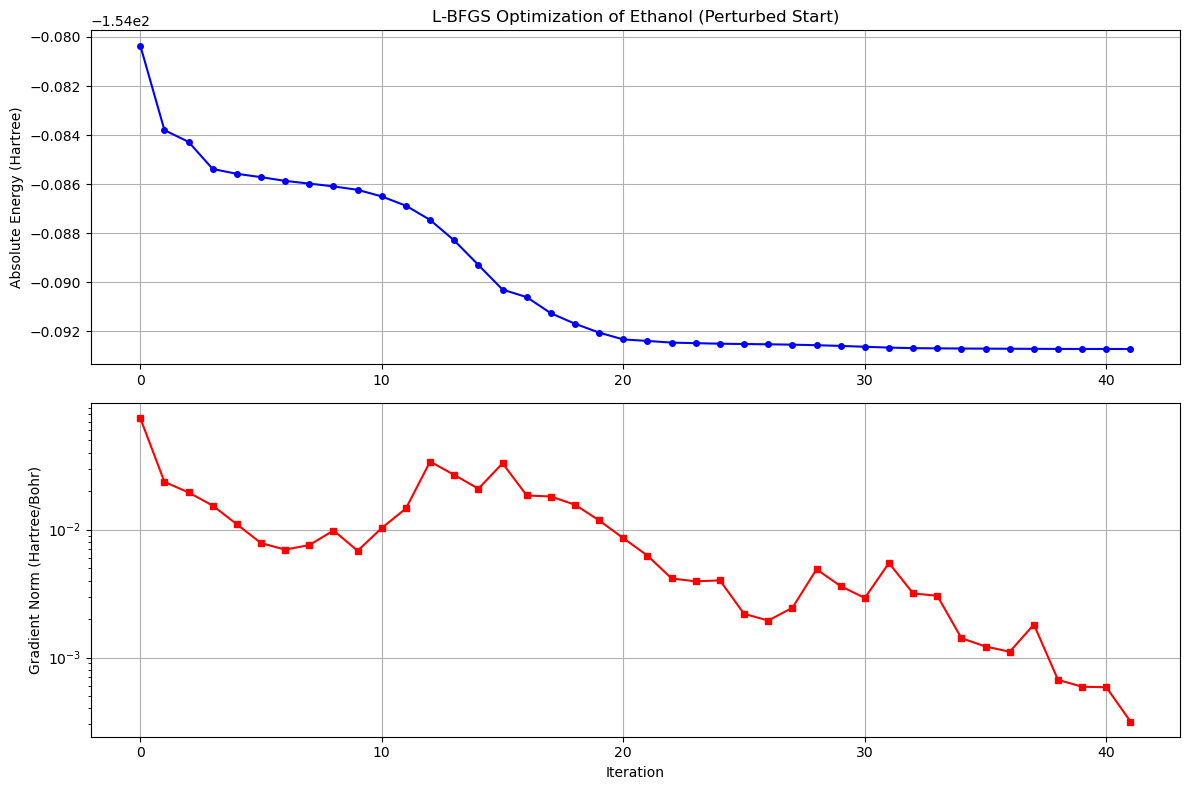

In [ ]:
print("\n优化完成！")
print(f"最终能量: {res.fun:.6f} Hartree")
print(f"收敛标志: {res.success}, 迭代次数: {len(history['energy'])}")

# 输出优化后的最终坐标
print("\n优化后的笛卡尔坐标 (Å):")
final_coords = res.x.reshape(natom, 3)
for i, sym in enumerate(atom_symbols):
    x, y, z = final_coords[i]
    print(f"{sym:2s}  {x:8.4f}  {y:8.4f}  {z:8.4f}")
    
# ------------------ 4. 可视化 ------------------
energies = np.array(history['energy'])
grad_norms = np.array(history['grad_norm'])
rel_energies = energies - energies[0]

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(energies, 'b-o', markersize=4)
plt.ylabel('Absolute Energy (Hartree)')
plt.title('L-BFGS Optimization of Ethanol (Perturbed Start)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogy(grad_norms, 'r-s', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Gradient Norm (Hartree/Bohr)')
plt.grid(True)

plt.tight_layout()
plt.savefig('lbfgs_ethanol.png', dpi=150)
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pyscf import gto, scf, grad
from rdkit import Chem
from rdkit.Chem import AllChem
import warnings
warnings.filterwarnings('ignore')

# ------------------ 1. 生成乙醇初始分子（带扰动） ------------------
def get_ethanol_init(seed=42, perturb_strength=0.0):
    mol = Chem.MolFromSmiles('CCO')
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=seed)
    atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    conf = mol.GetConformer()
    coords = conf.GetPositions()
    if perturb_strength > 0:
        np.random.seed(seed)
        perturbation = np.random.uniform(-perturb_strength, perturb_strength, size=coords.shape)
        coords += perturbation
    return mol, atom_symbols, coords

# 设置扰动强度
perturb = 0.5
mol_rdkit, atom_symbols, init_coords_ang = get_ethanol_init(seed=42, perturb_strength=perturb)
natom = len(atom_symbols)
print("原子符号:", atom_symbols)
print(f"初始坐标（已扰动 ±{perturb} Å）:\n", init_coords_ang)

# ------------------ 2. PySCF 能量和梯度计算 ------------------
def energy_grad_pyscf(atom_symbols, coords_ang):
    atom_str = '\n'.join([f"{atom_symbols[i]}  {coords_ang[i,0]:.8f}  {coords_ang[i,1]:.8f}  {coords_ang[i,2]:.8f}" 
                          for i in range(len(atom_symbols))])
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = 'cc-pvdz'
    mol.unit = 'angstrom'
    mol.build(verbose=0)
    mf = scf.RHF(mol)
    mf.kernel()
    energy = mf.e_tot
    g = grad.RHF(mf)
    grad_au = g.kernel()
    return energy, grad_au.flatten()

# ------------------ 3. L-BFGS 优化（笛卡尔坐标） ------------------
x0 = init_coords_ang.flatten()
history = {'energy': [], 'grad_norm': []}

def callback(xk):
    e, g = energy_grad_pyscf(atom_symbols, xk.reshape(natom, 3))
    history['energy'].append(e)
    history['grad_norm'].append(np.linalg.norm(g))
    print(f"Iter {len(history['energy'])-1:3d}: Energy = {e:.8f} Hartree, |grad| = {np.linalg.norm(g):.6}")

def fun(x):
    e, _ = energy_grad_pyscf(atom_symbols, x.reshape(natom, 3))
    return e

def jac(x):
    _, g = energy_grad_pyscf(atom_symbols, x.reshape(natom, 3))
    return g

print("="*60)
print("L-BFGS 优化开始")
print("="*60)
res = minimize(fun, x0, method='L-BFGS-B', jac=jac, callback=callback,
               options={'maxiter': 100, 'gtol': 1e-5})

print("\n优化完成！")
print(f"最终能量: {res.fun:.8f} Hartree")
print(f"收敛标志: {res.success}, 迭代次数: {len(history['energy'])}")


/home/liuzhe/miniconda3/envs/gpr_env/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


原子符号: ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']
初始坐标（已扰动 ±0.5 Å）:
 [[-1.07891507  0.49851852  0.27449332]
 [ 0.58657717 -0.66552068 -0.53305522]
 [ 0.83506114  0.69095982  0.83878825]
 [-1.14894003  0.25455969 -0.26331271]
 [-1.2608783  -1.15023072 -0.29641556]
 [-1.38762677  0.4006816   1.03591919]
 [ 0.71935107 -0.34937954 -1.12392143]
 [ 0.22952174 -1.63396501 -0.17766864]
 [ 1.78855985  1.333001    0.08865603]]
L-BFGS 优化开始
Iter   0: Energy = -153.09560330 Hartree, |grad| = 1.25741
Iter   1: Energy = -153.40591597 Hartree, |grad| = 0.35528
Iter   2: Energy = -153.47549296 Hartree, |grad| = 0.323727
Iter   3: Energy = -153.54325949 Hartree, |grad| = 0.294493
Iter   4: Energy = -153.67618591 Hartree, |grad| = 0.233661
Iter   5: Energy = -153.72884468 Hartree, |grad| = 0.199984
Iter   6: Energy = -153.78031233 Hartree, |grad| = 0.167861
Iter   7: Energy = -153.81596310 Hartree, |grad| = 0.211964
Iter   8: Energy = -153.85365612 Hartree, |grad| = 0.177822
Iter   9: Energy = -153.879


优化完成！
最终能量: -153.91088477 Hartree
收敛标志: True, 迭代次数: 64

优化后的笛卡尔坐标 (Å):
C    -0.4501    0.5445    0.2667
C     0.8008   -0.2540    0.0360
O     1.5815    0.5421    0.9134
H    -2.6420   -0.3811   -1.2497
H    -2.8906   -1.0870   -1.2300
H    -0.8964    0.1459    1.1916
H     1.1807   -0.2254   -0.9860
H     0.8347   -1.2777    0.4084
H     1.7640    1.3713    0.4931


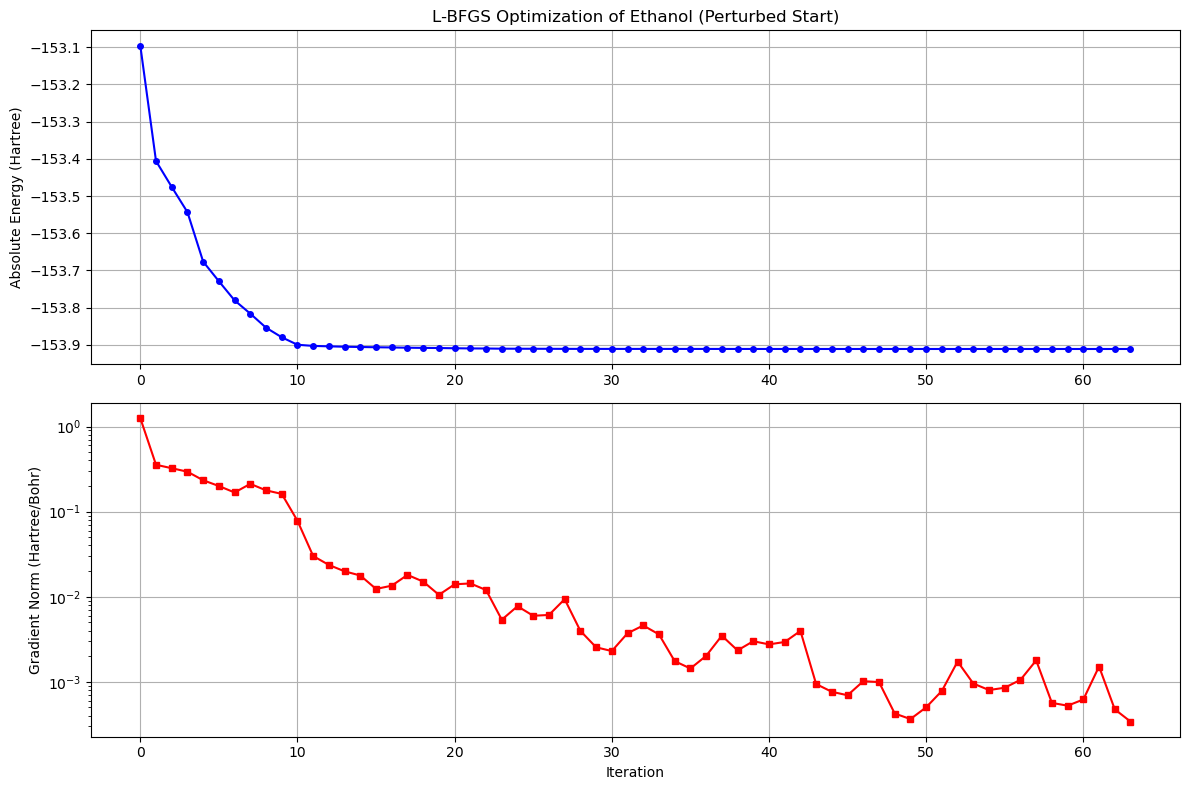

In [2]:
print("\n优化完成！")
print(f"最终能量: {res.fun:.8f} Hartree")
print(f"收敛标志: {res.success}, 迭代次数: {len(history['energy'])}")

# 输出优化后的最终坐标
print("\n优化后的笛卡尔坐标 (Å):")
final_coords = res.x.reshape(natom, 3)
for i, sym in enumerate(atom_symbols):
    x, y, z = final_coords[i]
    print(f"{sym:2s}  {x:8.4f}  {y:8.4f}  {z:8.4f}")
# ------------------ 4. 可视化 ------------------
energies = np.array(history['energy'])
grad_norms = np.array(history['grad_norm'])
rel_energies = energies - energies[0]

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(energies, 'b-o', markersize=4)
plt.ylabel('Absolute Energy (Hartree)')
plt.title('L-BFGS Optimization of Ethanol (Perturbed Start)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogy(grad_norms, 'r-s', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Gradient Norm (Hartree/Bohr)')
plt.grid(True)

plt.tight_layout()
plt.savefig('lbfgs_ethanol.png', dpi=150)
plt.show()